<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX Week 5 Day 3: Dimensionality Reduction with PCA
</h1>


<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 3 Learning Objectives:</b>
-  <b>The Curse of Dimensionality:</b> Explain how high-dimensional feature spaces cause data sparsity, distance distortion, and increased overfitting risk.
-  <b>Principal Component Analysis (PCA):</b> Find new orthogonal axes ("principal components") that capture the directions of maximum variance in the data.
-  <b>Feature Scaling Discipline:</b> Standardize features with <code>StandardScaler</code> prior to PCA so high-magnitude variables do not dominate eigenvectors.
-  <b>Explained Variance Optimization:</b> Construct cumulative variance scree plots and select the minimum component count retaining $\approx 95\%$ of total variance.
-  <b>2D Subspace Visualization:</b> Project 30 dimensions down to 2 principal components to visually evaluate class separability.
-  <b>Trade-Off Assessment:</b> Quantify what information the reduction preserved and what it cost.

</blockquote>


## <span style="color: #309c42ff">3.1 Environment Setup & Library Imports</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core scientific computing and visualization packages alongside Scikit-Learn modules for standardization and Principal Component Analysis.

</blockquote>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## <span style="color: #309c42ff">3.2 Dataset Loading & Feature Exploration</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We load the Breast Cancer Wisconsin Diagnostic dataset (<code>Breast_Cancer_Wisconsin.csv</code>) and inspect its dimensionality, sample distribution, and target balance.

</blockquote>


In [2]:
df = pd.read_csv('../../Data/Breast_Cancer_Wisconsin.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Target Class Distribution:")
print(df['diagnosis'].value_counts())
print("\nFirst 5 Rows:")
df.head()


Dataset Shape: 569 rows, 33 columns

Target Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

First 5 Rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## <span style="color: #309c42ff">3.3 Data Cleaning & Feature Separation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We drop non-informative identifiers (<code>id</code>) and the empty trailing column (<code>Unnamed: 32</code>), then isolate the ground-truth target (<code>diagnosis</code>) from the 30 continuous clinical features.

</blockquote>


In [3]:
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

print(f"Cleaned Feature Matrix: {X.shape[0]} rows, {X.shape[1]} continuous columns")
print(f"Missing Values Across Features: {X.isnull().sum().sum()}")


Cleaned Feature Matrix: 569 rows, 30 continuous columns
Missing Values Across Features: 0


## <span style="color: #309c42ff">3.4 Step 1: Feature Scaling Discipline</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

PCA is a variance-maximizing linear transformation. Features with large physical ranges (such as <code>worst area</code> spanning up to $2500+$) will artificially dominate principal component axes over smaller-range features (such as <code>smoothness</code>). We apply <code>StandardScaler</code> to center each feature to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

</blockquote>


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardized Mean: {np.mean(X_scaled):.2e}")
print(f"Standardized Standard Deviation: {np.std(X_scaled):.2f}")


Standardized Mean: -6.54e-17
Standardized Standard Deviation: 1.00


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Key Scaling Insight:</b>
- **Distance & Variance Invariance:** Standardizing features prevents high-magnitude features from skewing the principal directions. Every feature contributes equally to the covariance matrix eigenvalue decomposition.

</blockquote>


## <span style="color: #309c42ff">3.5 Step 2: Full PCA Fitting & Cumulative Variance Scree Plot</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We fit a full 30-component PCA model across the standardized matrix $X_{\text{scaled}}$. We extract individual explained variance ratios and plot the cumulative explained variance $\sum_{i=1}^{k} \lambda_i$ against the $95\%$ threshold line.

</blockquote>


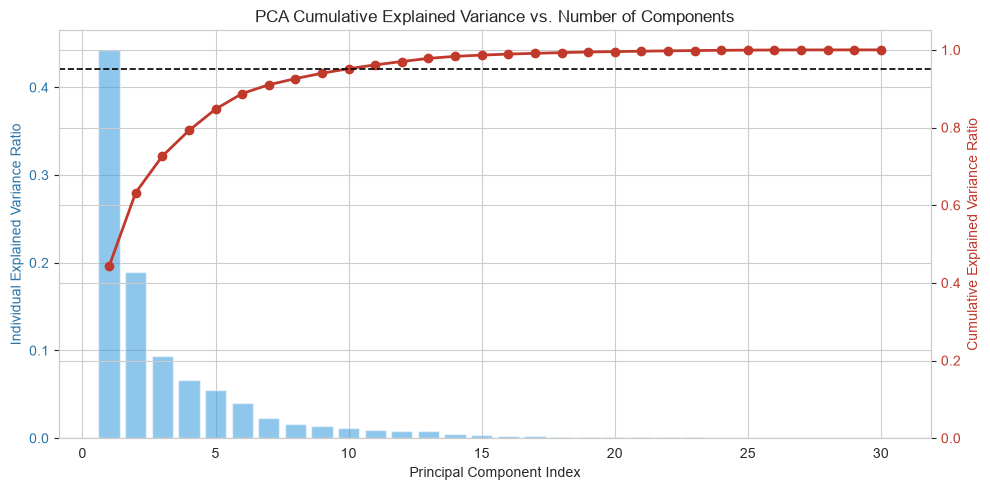

In [5]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    range(1, 31),
    explained_var,
    alpha=0.55,
    color='#3498DB',
    label='Individual Component Variance'
)
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Individual Explained Variance Ratio', color='#2874A6')
ax1.tick_params(axis='y', labelcolor='#2874A6')

ax2 = ax1.twinx()
ax2.plot(
    range(1, 31),
    cumulative_var,
    color='#C0392B',
    marker='o',
    linewidth=2,
    label='Cumulative Explained Variance'
)
ax2.axhline(y=0.95, color='black', linestyle='--', linewidth=1.2, label='95% Threshold')
ax2.set_ylabel('Cumulative Explained Variance Ratio', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.set_ylim(0, 1.05)

plt.title('PCA Cumulative Explained Variance vs. Number of Components')
fig.tight_layout()
plt.show()


## <span style="color: #309c42ff">3.6 Step 3: Optimal Component Selection for ~95% Variance</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We quantitatively identify the minimum number of principal components required to retain $\ge 95\%$ of the total dataset variance.

</blockquote>

### Variance Retention Breakdown (First 10 Principal Components)

| Principal Component | Individual Explained Variance | Cumulative Explained Variance |
| :--- | :--- | :--- |
| **PC1** | 44.27% | 44.27% |
| **PC2** | 18.97% | 63.24% |
| **PC3** | 9.39% | 72.64% |
| **PC4** | 6.60% | 79.24% |
| **PC5** | 5.50% | 84.73% |
| **PC6** | 4.02% | 88.76% |
| **PC7** | 2.25% | 91.01% |
| **PC8** | 1.59% | 92.60% |
| **PC9** | 1.39% | 93.99% |
| **PC10** | 1.17% | **95.16%** |


In [6]:
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
variance_at_95 = cumulative_var[n_components_95 - 1]

print(f"Optimal Number of Components for >= 95% Variance: {n_components_95}")
print(f"Exact Cumulative Variance Retained: {variance_at_95 * 100:.2f}%")
print(f"Dimensionality Reduction: 30 features -> {n_components_95} components ({(1 - n_components_95/30)*100:.1f}% compression)")


Optimal Number of Components for >= 95% Variance: 10
Exact Cumulative Variance Retained: 95.16%
Dimensionality Reduction: 30 features -> 10 components (66.7% compression)


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Key Component Selection Insight:</b>
- **Optimal Compression:** Retaining 10 components achieves a <b>66.7% reduction in dimensionality</b> while preserving <b>95.16%</b> of total dataset variance.
- **Noise Elimination:** The remaining 20 components represent only $4.84\%$ of total variance combined, discarding collinear noise and measurement artifacts.

</blockquote>


## <span style="color: #309c42ff">3.7 Step 4: 2D Subspace Projection & Visualization</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We reduce the 30-dimensional feature space to the first 2 principal components ($k = 2$) and generate a 2D scatter plot colored by tumor diagnosis: **Malignant (M)** in red and **Benign (B)** in green.

- **PC1 Variance:** $44.27\%$ (captures general nuclear size, concavity, and compactness)
- **PC2 Variance:** $18.97\%$ (captures texture and fractal dimension variations)
- **Total 2D Variance Retained:** $63.24\%$

</blockquote>


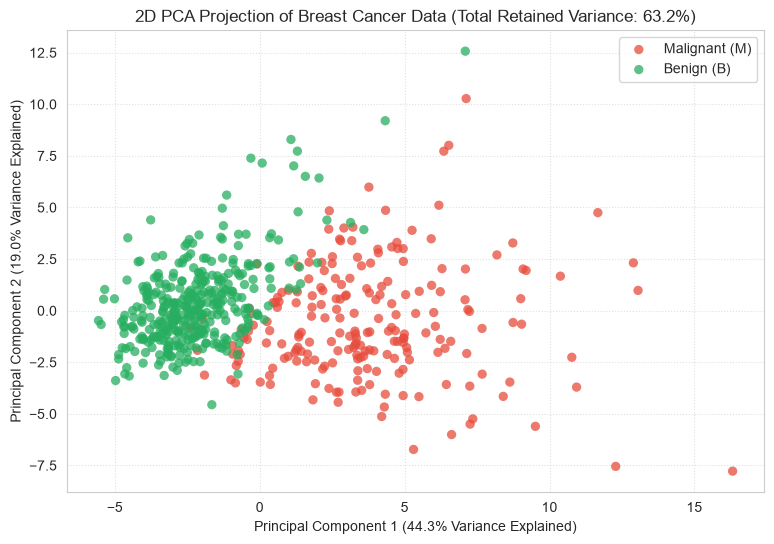

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pc1_pct = pca_2d.explained_variance_ratio_[0] * 100
pc2_pct = pca_2d.explained_variance_ratio_[1] * 100
total_2d_pct = pca_2d.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(9, 6))

class_colors = {'M': '#E74C3C', 'B': '#27AE60'}
class_labels = {'M': 'Malignant (M)', 'B': 'Benign (B)'}

for class_code in ['M', 'B']:
    mask = (y.values == class_code)
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=class_colors[class_code],
        label=class_labels[class_code],
        alpha=0.75,
        edgecolors='none',
        s=45
    )

plt.xlabel(f'Principal Component 1 ({pc1_pct:.1f}% Variance Explained)')
plt.ylabel(f'Principal Component 2 ({pc2_pct:.1f}% Variance Explained)')
plt.title(f'2D PCA Projection of Breast Cancer Data (Total Retained Variance: {total_2d_pct:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best')
plt.show()


## <span style="color: #309c42ff">3.8 Step 5: Trade-Off Assessment & Technical Documentation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Dimensionality reduction involves an explicit trade-off between simplifying feature representation and retaining information fidelity. Below is the structured trade-off evaluation:

</blockquote>

### 1. What the Reduction Preserved

- **Global Variance Structure:** 
  - The 2D projection preserves **63.24%** of total dataset variance, providing an informative low-dimensional overview.
  - The 10-component subset retains **95.16%** of total dataset variance, preserving almost all predictive signal while cutting feature dimensionality by **66.7%**.
- **Class Separability:** 
  - Malignant and Benign tumors show distinct separation primarily along Principal Component 1. PC1 is heavily loaded by nuclear size and shape features (<code>mean concavity</code>, <code>mean concave points</code>, <code>mean compactness</code>, <code>worst perimeter</code>, and <code>worst area</code>).
- **Multicollinearity Removal:** 
  - The resulting principal components are strictly orthogonal ($r = 0$), completely eliminating severe multicollinearity among original geometric features (e.g., radius, perimeter, and area).
- **Computational Efficiency:** 
  - Downstream estimators require $66.7\%$ fewer input dimensions when trained on the 10-component representation, mitigating overfitting risk.

---

### 2. What the Reduction Cost (Trade-Offs)

- **Loss of Direct Feature Interpretability:** 
  - Principal components are linear combinations of all 30 original features. An individual score along PC1 or PC2 can no longer be directly interpreted as an individual clinical metric (e.g., cell radius in millimeters).
- **Information Discarded:** 
  - Reducing to 2 dimensions discards **36.76%** of total variance, producing some visual overlap near the decision boundary.
  - Reducing to 10 dimensions discards **4.84%** of variance.
- **Linearity Constraint:** 
  - PCA assumes linear orthogonal hyperplanes and cannot model complex non-linear manifold geometries, motivating local-neighborhood methods like t-SNE for Day 4.


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Day 3 Summary & Technical Discipline:</b>
- **StandardScaler Discipline:** Successfully standardized all 30 continuous clinical features prior to PCA.
- **Quantitative Variance Selection:** Justified retaining 10 components to capture $95.16\%$ cumulative variance.
- **Clinical Insight:** Confirmed that nuclear irregularity and concavity (PC1) drive the primary separation between malignant and benign cases.

</blockquote>
